# 04 — Figures for Paper: Publication-Ready Outputs

**Paper:** XAI-Assisted Review and HITL Bottleneck Mitigation: A Queueing Theory Approach  

This notebook consolidates all analytical and simulation results from notebooks 01–03  
into **final publication-ready figures and tables** with consistent styling.

---

## Output map

| Figure | Content | Notebook source |
|--------|---------|----------------|
| Fig. 1 | System pipeline diagram (Stage structure) | — |
| Fig. 2 | Traffic intensity rho vs lambda, all scenarios | NB01 |
| Fig. 3 | Mean waiting time Wq vs lambda (log scale) | NB01 |
| Fig. 4 | Weekly throughput by scenario (bar) | NB01 |
| Fig. 5 | Simulated vs analytical Wq with 95% CI | NB02 |
| Fig. 6 | Critical alpha vs arrival rate curve | NB03 |
| Fig. 7 | Bivariate heatmap: alpha x p -> E[S] | NB03 |

| Table | Content | Notebook source |
|-------|---------|----------------|
| Table 1 | Scenario parameter summary | NB01 |
| Table 2 | Simulation validation (sim vs P-K) | NB02 |
| Table 3 | Critical alpha at key lambda levels | NB03 |


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from scipy import stats
from scipy.optimize import brentq

# ── Directories ───────────────────────────────────────────────────────────────
FIG_DIR    = Path("figures")
TAB_DIR    = Path("tables")
PAPER_DIR  = Path("paper_figures")
PAPER_DIR.mkdir(exist_ok=True)

# ── Publication style ─────────────────────────────────────────────────────────
sns.set_theme(style="white")
plt.rcParams.update({
    "font.family":        "serif",
    "font.size":          11,
    "axes.titlesize":     12,
    "axes.labelsize":     12,
    "xtick.labelsize":    10,
    "ytick.labelsize":    10,
    "legend.fontsize":    10,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "axes.linewidth":     0.8,
    "grid.linewidth":     0.4,
    "grid.alpha":         0.5,
    "lines.linewidth":    2.0,
})

DPI    = 600
COLORS = {"S1": "#2166ac", "S2": "#f4a582", "S3": "#d6604d"}
LABELS = {
    "S1": "S1 (No XAI)",
    "S2": "S2 (Partial XAI)",
    "S3": "S3 (Full XAI)",
}
LS = {"S1": "-", "S2": "--", "S3": "-."}

print("Publication style loaded.")


Publication style loaded.


In [2]:
# ── Shared parameters and helpers ────────────────────────────────────────────
P_SMALL   = 0.70
S_SMALL_0 = 72.0
S_LARGE_0 =  5.0

SCENARIOS = {
    "S1": {"s_small": 72.0, "s_large": 5.0},
    "S2": {"s_small": 24.0, "s_large": 3.0},
    "S3": {"s_small":  8.0, "s_large": 1.5},
}

def moments(s_small, s_large, p=P_SMALL):
    ES  = p * s_small + (1 - p) * s_large
    ES2 = p * s_small**2 + (1 - p) * s_large**2
    mu  = 1.0 / ES
    return ES, ES2, mu

def pk_wq(lam, ES, ES2):
    rho = lam * ES
    if np.isscalar(lam):
        return np.inf if rho >= 1 else (lam * ES2) / (2 * (1 - rho))
    return np.where(rho < 1, (lam * ES2) / (2 * (1 - rho)), np.inf)

def apply_xai(alpha):
    return S_SMALL_0 / (1 + alpha), S_LARGE_0 / (1 + alpha / 3)

def throughput_weekly(mu, h=8, d=5):
    return mu * h * d

MOM = {k: moments(**v) for k, v in SCENARIOS.items()}
mu0 = MOM["S1"][2]   # baseline mu

print("Parameters ready.")
for k, (ES, ES2, mu) in MOM.items():
    print(f"  {LABELS[k]}: E[S]={ES:.2f}h  mu={mu:.5f}  weekly={throughput_weekly(mu):.2f}")


Parameters ready.
  S1 (No XAI): E[S]=51.90h  mu=0.01927  weekly=0.77
  S2 (Partial XAI): E[S]=17.70h  mu=0.05650  weekly=2.26
  S3 (Full XAI): E[S]=6.05h  mu=0.16529  weekly=6.61


---
## Figure 1 — System Pipeline Diagram

Illustrates the eight-stage evaluation pipeline, distinguishing AI-automated stages from HITL stages,
and highlighting Stage 5 as the primary bottleneck.


C:\Users\ecredible\AppData\Local\Temp\ipykernel_21448\78635123.py:82: UserWarning: Glyph 9319 (\N{CIRCLED DIGIT EIGHT}) missing from font(s) DejaVu Serif.
  plt.tight_layout()
C:\Users\ecredible\AppData\Local\Temp\ipykernel_21448\78635123.py:82: UserWarning: Glyph 9318 (\N{CIRCLED DIGIT SEVEN}) missing from font(s) DejaVu Serif.
  plt.tight_layout()
C:\Users\ecredible\AppData\Local\Temp\ipykernel_21448\78635123.py:82: UserWarning: Glyph 9317 (\N{CIRCLED DIGIT SIX}) missing from font(s) DejaVu Serif.
  plt.tight_layout()
C:\Users\ecredible\AppData\Local\Temp\ipykernel_21448\78635123.py:82: UserWarning: Glyph 9316 (\N{CIRCLED DIGIT FIVE}) missing from font(s) DejaVu Serif.
  plt.tight_layout()
C:\Users\ecredible\AppData\Local\Temp\ipykernel_21448\78635123.py:82: UserWarning: Glyph 9315 (\N{CIRCLED DIGIT FOUR}) missing from font(s) DejaVu Serif.
  plt.tight_layout()
C:\Users\ecredible\AppData\Local\Temp\ipykernel_21448\78635123.py:82: UserWarning: Glyph 9314 (\N{CIRCLED DIGIT THREE}) miss

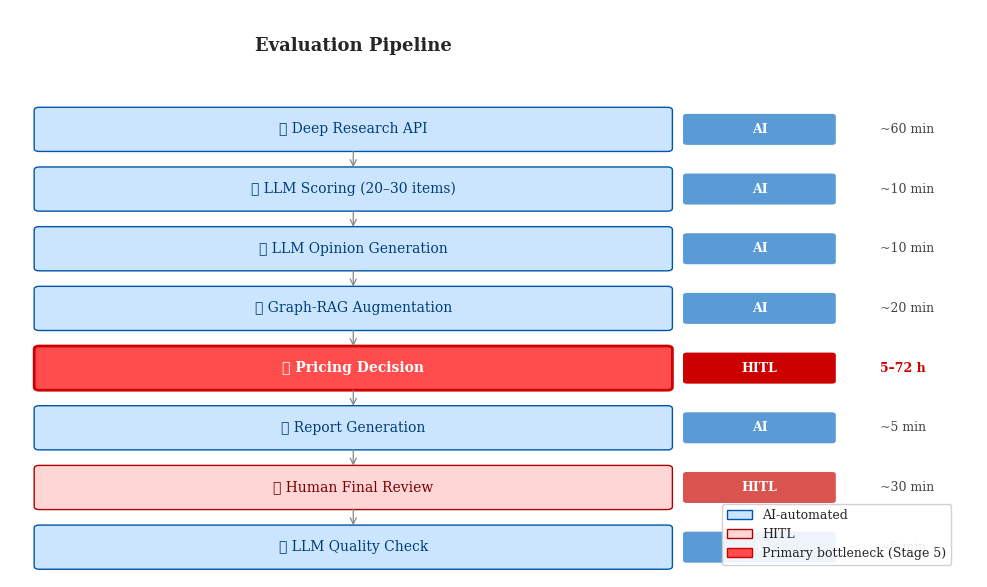

Saved -> paper_figures/paper_fig1_pipeline.png


In [3]:
# ── Figure 1: System pipeline diagram ────────────────────────────────────────

stages = [
    ("① Deep Research API",      "AI",    60,  False),
    ("② LLM Scoring (20–30 items)","AI",  10,  False),
    ("③ LLM Opinion Generation", "AI",    10,  False),
    ("④ Graph-RAG Augmentation", "AI",    20,  False),
    ("⑤ Pricing Decision",       "HITL",  None,True),
    ("⑥ Report Generation",      "AI",    5,   False),
    ("⑦ Human Final Review",     "HITL",  30,  False),
    ("⑧ LLM Quality Check",      "AI",    5,   False),
]

COLOR_AI   = "#cce5ff"
COLOR_HITL = "#ffd6d6"
COLOR_BN   = "#ff4d4d"
COLOR_TEXT_AI   = "#003d7a"
COLOR_TEXT_HITL = "#7a0000"

fig, ax = plt.subplots(figsize=(10, 6))
ax.set_xlim(0, 10)
ax.set_ylim(0, len(stages) + 1.5)
ax.axis("off")

for i, (name, agent, dur, is_bottleneck) in enumerate(reversed(stages)):
    y   = i + 0.5
    fc  = COLOR_BN if is_bottleneck else (COLOR_HITL if agent == "HITL" else COLOR_AI)
    ec  = "#cc0000" if is_bottleneck else ("#aa0000" if agent == "HITL" else "#0055aa")
    lw  = 2.0 if is_bottleneck else 1.0
    tc  = "white" if is_bottleneck else (COLOR_TEXT_HITL if agent == "HITL" else COLOR_TEXT_AI)

    # Box
    rect = mpatches.FancyBboxPatch(
        (0.3, y - 0.32), 6.5, 0.64,
        boxstyle="round,pad=0.05",
        facecolor=fc, edgecolor=ec, linewidth=lw
    )
    ax.add_patch(rect)

    # Stage label
    ax.text(3.55, y, name, ha="center", va="center",
            fontsize=10, color=tc,
            fontweight="bold" if is_bottleneck else "normal")

    # Agent badge
    badge_fc = "#cc0000" if is_bottleneck else ("#d9534f" if agent == "HITL" else "#5b9bd5")
    badge = mpatches.FancyBboxPatch(
        (7.0, y - 0.22), 1.5, 0.44,
        boxstyle="round,pad=0.04",
        facecolor=badge_fc, edgecolor="none"
    )
    ax.add_patch(badge)
    ax.text(7.75, y, agent, ha="center", va="center",
            fontsize=9, color="white", fontweight="bold")

    # Duration label
    if dur is not None:
        ax.text(9.0, y, f"~{dur} min", ha="left", va="center",
                fontsize=9, color="#444444")
    else:
        ax.text(9.0, y, "5–72 h", ha="left", va="center",
                fontsize=9, color="#cc0000", fontweight="bold")

    # Arrow (except last)
    if i < len(stages) - 1:
        ax.annotate("", xy=(3.55, y + 0.32), xytext=(3.55, y + 0.68),
                    arrowprops=dict(arrowstyle="->", color="#888888", lw=0.9))

# Header
ax.text(3.55, len(stages) + 0.9, "Evaluation Pipeline",
        ha="center", va="center", fontsize=13, fontweight="bold")

# Legend
legend_items = [
    mpatches.Patch(facecolor=COLOR_AI,   edgecolor="#0055aa", label="AI-automated"),
    mpatches.Patch(facecolor=COLOR_HITL, edgecolor="#aa0000", label="HITL"),
    mpatches.Patch(facecolor=COLOR_BN,   edgecolor="#cc0000", label="Primary bottleneck (Stage 5)"),
]
ax.legend(handles=legend_items, loc="lower right",
          bbox_to_anchor=(0.98, 0.01), fontsize=9, framealpha=0.9)

plt.tight_layout()
plt.savefig(PAPER_DIR / "paper_fig1_pipeline.png", dpi=DPI, bbox_inches="tight")
plt.show()
print("Saved -> paper_figures/paper_fig1_pipeline.png")


---
## Figure 2 — Traffic Intensity vs Arrival Rate

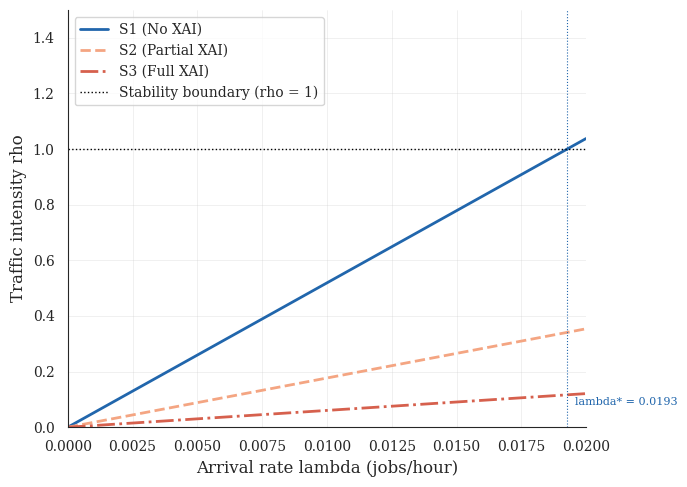

Saved -> paper_figures/paper_fig2_rho_lambda.png


In [4]:
# ── Figure 2: rho vs lambda ──────────────────────────────────────────────────
lam_range = np.linspace(0, 0.020, 600)

fig, ax = plt.subplots(figsize=(7, 5))

for k in ["S1", "S2", "S3"]:
    ES, ES2, mu = MOM[k]
    ax.plot(lam_range, lam_range * ES,
            color=COLORS[k], linestyle=LS[k],
            label=LABELS[k])

ax.axhline(1.0, color="black", linewidth=1.0, linestyle=":",
           label="Stability boundary (rho = 1)")

# Annotate S1 critical lambda
ax.axvline(mu0, color=COLORS["S1"], linewidth=0.8, linestyle=":")
ax.text(mu0 + 0.0003, 0.08,
        "lambda* = {:.4f}".format(mu0),
        fontsize=8, color=COLORS["S1"])

ax.set_xlabel("Arrival rate lambda (jobs/hour)")
ax.set_ylabel("Traffic intensity rho")
ax.set_xlim(0, 0.020)
ax.set_ylim(0, 1.5)
ax.legend(loc="upper left")
ax.grid(True)

plt.tight_layout()
plt.savefig(PAPER_DIR / "paper_fig2_rho_lambda.png", dpi=DPI, bbox_inches="tight")
plt.show()
print("Saved -> paper_figures/paper_fig2_rho_lambda.png")


---
## Figure 3 — Mean Waiting Time vs Arrival Rate

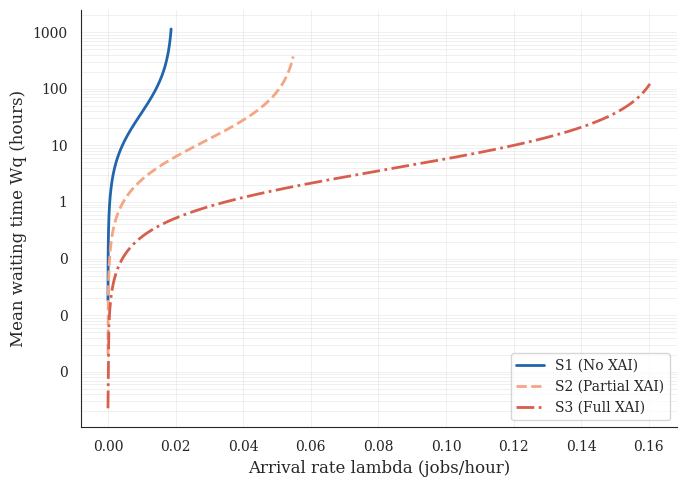

Saved -> paper_figures/paper_fig3_Wq_lambda.png


In [5]:
# ── Figure 3: Wq vs lambda (log scale) ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))

for k in ["S1", "S2", "S3"]:
    ES, ES2, mu = MOM[k]
    lam = np.linspace(1e-5, mu * 0.97, 600)
    Wq  = pk_wq(lam, ES, ES2)
    ax.plot(lam, Wq, color=COLORS[k], linestyle=LS[k], label=LABELS[k])

ax.set_xlabel("Arrival rate lambda (jobs/hour)")
ax.set_ylabel("Mean waiting time Wq (hours)")
ax.set_yscale("log")
ax.yaxis.set_major_formatter(mticker.ScalarFormatter())
ax.legend(loc="lower right")
ax.grid(True, which="both")

plt.tight_layout()
plt.savefig(PAPER_DIR / "paper_fig3_Wq_lambda.png", dpi=DPI, bbox_inches="tight")
plt.show()
print("Saved -> paper_figures/paper_fig3_Wq_lambda.png")


---
## Figure 4 — Weekly Throughput by Scenario

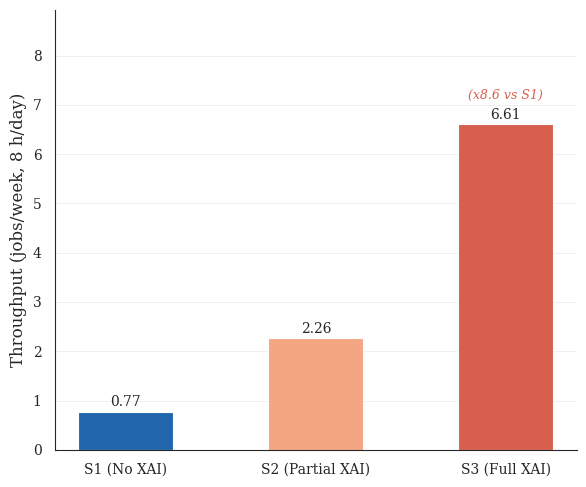

Saved -> paper_figures/paper_fig4_throughput.png


In [6]:
# -- Figure 4: Weekly throughput bar chart -----------------------------------
keys   = ['S1', 'S2', 'S3']
tputs  = [throughput_weekly(MOM[k][2]) for k in keys]
labels = [LABELS[k] for k in keys]
colors = [COLORS[k] for k in keys]

fig, ax = plt.subplots(figsize=(6, 5))

bars = ax.bar(labels, tputs, color=colors, width=0.5,
              edgecolor='white', linewidth=0.8)

# Value labels on each bar
for bar, val in zip(bars, tputs):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.05,
            '{:.2f}'.format(val),
            ha='center', va='bottom', fontsize=10)

# x8.6 annotation — placed inside parentheses just above the S3 value label
ratio  = tputs[2] / tputs[0]
s3_bar = bars[2]
ax.text(
    s3_bar.get_x() + s3_bar.get_width() / 2,
    tputs[2] + 0.45,
    '(x{:.1f} vs S1)'.format(ratio),
    ha='center', va='bottom',
    fontsize=9, color=COLORS['S3'],
    fontstyle='italic'
)

ax.set_ylabel('Throughput (jobs/week, 8 h/day)')
ax.set_ylim(0, max(tputs) * 1.35)
ax.grid(axis='y')

plt.tight_layout()
plt.savefig(PAPER_DIR / 'paper_fig4_throughput.png', dpi=DPI, bbox_inches='tight')
plt.show()
print('Saved -> paper_figures/paper_fig4_throughput.png')


---
## Figure 5 — Simulation Validation: Simulated vs Analytical Wq

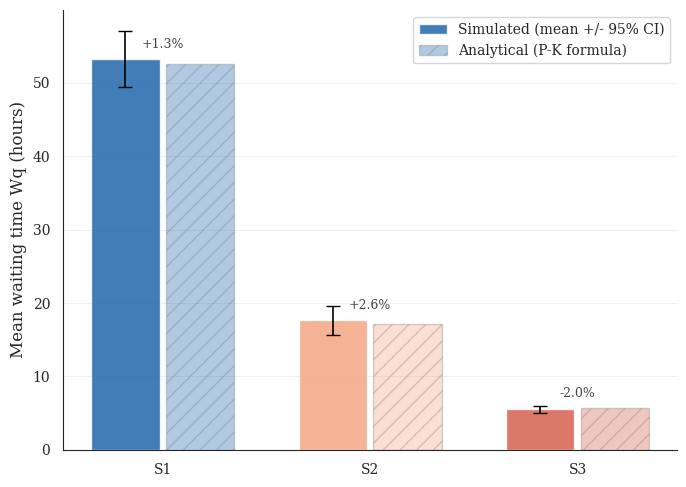

Saved -> paper_figures/paper_fig5_validation.png


In [7]:
# ── Figure 5: Sim vs analytical — load from saved CSV ────────────────────────
df_val = pd.read_csv(TAB_DIR / "table4_validation.csv", index_col="Scenario")

keys_ordered = ["S1 (No XAI)", "S2 (Partial XAI)", "S3 (Full XAI)"]
color_list   = [COLORS["S1"], COLORS["S2"], COLORS["S3"]]
x_pos        = np.arange(3)

sim_means  = df_val.loc[keys_ordered, "Wq simulated mean (h)"].values
ci_lo      = df_val.loc[keys_ordered, "95% CI lower"].values
ci_hi      = df_val.loc[keys_ordered, "95% CI upper"].values
analytical = df_val.loc[keys_ordered, "Wq analytical (h)"].values

err_lo = sim_means - ci_lo
err_hi = ci_hi - sim_means

fig, ax = plt.subplots(figsize=(7, 5))

ax.bar(x_pos - 0.18, sim_means, width=0.33,
       color=color_list, alpha=0.85,
       label="Simulated (mean +/- 95% CI)", edgecolor="white")
ax.errorbar(x_pos - 0.18, sim_means,
            yerr=[err_lo, err_hi],
            fmt="none", color="black", capsize=5, linewidth=1.2)

ax.bar(x_pos + 0.18, analytical, width=0.33,
       color=color_list, alpha=0.35,
       label="Analytical (P-K formula)",
       edgecolor="gray", hatch="//")

ax.set_xticks(x_pos)
ax.set_xticklabels(["S1", "S2", "S3"])
ax.set_ylabel("Mean waiting time Wq (hours)")

# Error % annotations
for i, (s, a) in enumerate(zip(sim_means, analytical)):
    pct = (s - a) / a * 100
    ax.text(x_pos[i], max(s, a) + 1.5,
            "{:+.1f}%".format(pct),
            ha="center", fontsize=9, color="#444444")

ax.legend(loc="upper right")
ax.grid(axis="y")

plt.tight_layout()
plt.savefig(PAPER_DIR / "paper_fig5_validation.png", dpi=DPI, bbox_inches="tight")
plt.show()
print("Saved -> paper_figures/paper_fig5_validation.png")


---
## Figure 6 — Critical Alpha vs Arrival Rate

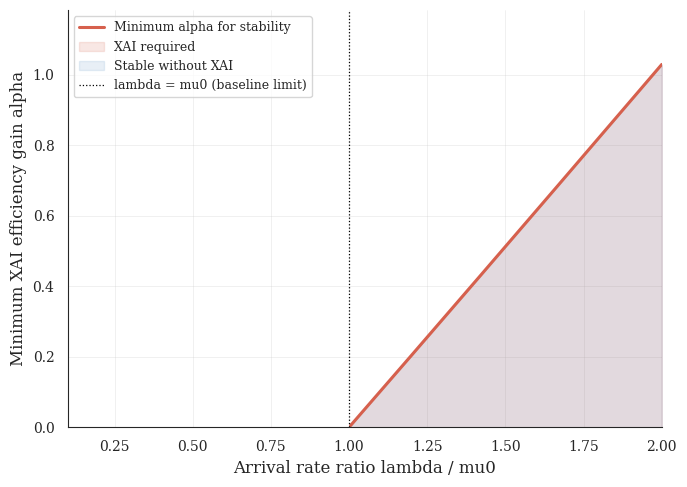

Saved -> paper_figures/paper_fig6_critical_alpha.png


In [8]:
# ── Figure 6: Critical alpha curve ──────────────────────────────────────────

def alpha_critical(lam, p_small=P_SMALL):
    ES0, _, _ = moments(S_SMALL_0, S_LARGE_0, p_small)
    if lam * ES0 < 1:
        return 0.0
    def f(a):
        ss, sl   = apply_xai(a)
        ES, _, _ = moments(ss, sl, p_small)
        return lam * ES - 1.0
    try:
        return brentq(f, 0, 300)
    except ValueError:
        return np.nan

lam_sweep = np.linspace(0.1 * mu0, 2.0 * mu0, 400)
alpha_crit = np.array([alpha_critical(l) for l in lam_sweep])

mask = alpha_crit > 0
lam_plot   = lam_sweep[mask]
alpha_plot = alpha_crit[mask]

fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(lam_plot / mu0, alpha_plot,
        color="#d6604d", linewidth=2.2,
        label="Minimum alpha for stability")
ax.fill_between(lam_plot / mu0, alpha_plot,
                alpha=0.15, color="#d6604d",
                label="XAI required")
ax.fill_between(lam_plot / mu0, 0, alpha_plot,
                alpha=0.10, color="#2166ac",
                label="Stable without XAI")
ax.axvline(1.0, color="black", linewidth=0.9, linestyle=":",
           label="lambda = mu0 (baseline limit)")

# Scenario reference lines
for k, a_ref, rho_ref in [("S2", 2.94, 0.60), ("S3", 8.58, 0.60)]:
    ax.scatter(rho_ref, a_ref, color=COLORS[k], zorder=5, s=60)
    ax.annotate(LABELS[k],
                xy=(rho_ref, a_ref),
                xytext=(rho_ref + 0.05, a_ref + 0.8),
                fontsize=9, color=COLORS[k],
                arrowprops=dict(arrowstyle="-", color=COLORS[k], lw=0.7))

ax.set_xlabel("Arrival rate ratio lambda / mu0")
ax.set_ylabel("Minimum XAI efficiency gain alpha")
ax.set_xlim(lam_sweep[0] / mu0, lam_sweep[-1] / mu0)
ax.set_ylim(0, max(alpha_plot) * 1.15 if len(alpha_plot) > 0 else 20)
ax.legend(loc="upper left", fontsize=9)
ax.grid(True)

plt.tight_layout()
plt.savefig(PAPER_DIR / "paper_fig6_critical_alpha.png", dpi=DPI, bbox_inches="tight")
plt.show()
print("Saved -> paper_figures/paper_fig6_critical_alpha.png")


---
## Figure 7 — Bivariate Heatmap: Alpha x p -> E[S]

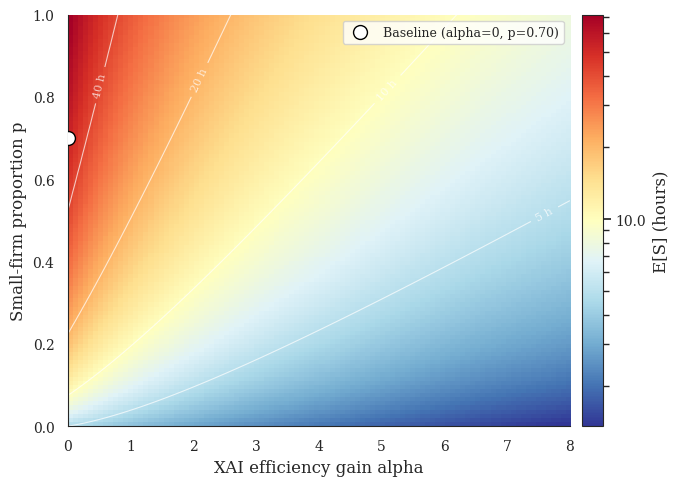

Saved -> paper_figures/paper_fig7_heatmap.png


In [9]:
# ── Figure 7: Bivariate heatmap alpha x p -> E[S] ───────────────────────────
alpha_g = np.linspace(0, 8, 100)
p_g     = np.linspace(0, 1, 100)
ES_map  = np.zeros((len(p_g), len(alpha_g)))

for i, p in enumerate(p_g):
    for j, a in enumerate(alpha_g):
        ss, sl       = apply_xai(a)
        ES, _, _     = moments(ss, sl, p)
        ES_map[i, j] = ES

fig, ax = plt.subplots(figsize=(7, 5))

im = ax.imshow(
    ES_map,
    aspect="auto", origin="lower",
    extent=[alpha_g[0], alpha_g[-1], p_g[0], p_g[-1]],
    cmap="RdYlBu_r",
    norm=mcolors.LogNorm(
        vmin=np.nanmin(ES_map[ES_map > 0]),
        vmax=np.nanmax(ES_map)
    ),
)
cbar = plt.colorbar(im, ax=ax, pad=0.02)
cbar.set_label("E[S] (hours)")
cbar.ax.yaxis.set_major_formatter(mticker.ScalarFormatter())

# Contour overlay
cs = ax.contour(
    alpha_g, p_g, ES_map,
    levels=[5, 10, 20, 40],
    colors="white", linewidths=0.8, alpha=0.7
)
ax.clabel(cs, fmt="%g h", fontsize=8, colors="white")

# Mark baseline
ax.scatter(0, P_SMALL, color="white", edgecolors="black",
           s=100, zorder=5, label="Baseline (alpha=0, p=0.70)")

ax.set_xlabel("XAI efficiency gain alpha")
ax.set_ylabel("Small-firm proportion p")
ax.legend(loc="upper right", fontsize=9)

plt.tight_layout()
plt.savefig(PAPER_DIR / "paper_fig7_heatmap.png", dpi=DPI, bbox_inches="tight")
plt.show()
print("Saved -> paper_figures/paper_fig7_heatmap.png")


---
## Paper Tables

Three tables formatted for direct inclusion in the manuscript.


In [10]:
# ── Paper Table 1: Scenario parameter summary ────────────────────────────────
rows = []
for k in ["S1", "S2", "S3"]:
    v        = SCENARIOS[k]
    ES, ES2, mu = MOM[k]
    VarS     = ES2 - ES**2
    alpha    = mu / MOM["S1"][2] - 1
    rows.append({
        "Scenario":                LABELS[k],
        "s_small (h)":             v["s_small"],
        "s_large (h)":             v["s_large"],
        "E[S] (h)":                round(ES, 2),
        "Var[S]":                  round(VarS, 1),
        "sigma[S] (h)":            round(np.sqrt(VarS), 1),
        "mu (jobs/h)":             round(mu, 5),
        "Throughput (jobs/wk)":    round(throughput_weekly(mu), 2),
        "Capacity ratio vs S1":    round(mu / MOM["S1"][2], 2),
    })

df_t1 = pd.DataFrame(rows).set_index("Scenario")
print("=== Paper Table 1: Scenario Parameters ===")
print(df_t1.to_string())
df_t1.to_csv(PAPER_DIR / "paper_table1_scenarios.csv")
print()

# ── Paper Table 2: Simulation validation ─────────────────────────────────────
df_t2 = pd.read_csv(TAB_DIR / "table4_validation.csv", index_col="Scenario")
print("=== Paper Table 2: Simulation Validation ===")
print(df_t2.to_string())
df_t2.to_csv(PAPER_DIR / "paper_table2_validation.csv")
print()

# ── Paper Table 3: Critical alpha ────────────────────────────────────────────
key_mults = [0.5, 0.8, 1.0, 1.2, 1.5, 2.0, 3.0]
rows3 = []
for m in key_mults:
    lam    = m * mu0
    a_crit = alpha_critical(lam)
    ss, sl = apply_xai(a_crit) if a_crit > 0 else (S_SMALL_0, S_LARGE_0)
    ES_c, _, _ = moments(ss, sl)
    rows3.append({
        "lambda / mu0":             m,
        "lambda (jobs/h)":          round(lam, 5),
        "alpha_critical":           round(a_crit, 2),
        "s_small at alpha_c (h)":   round(ss, 1),
        "E[S] at alpha_c (h)":      round(ES_c, 2),
        "Stable at alpha=0":        "Yes" if a_crit == 0.0 else "No",
    })
df_t3 = pd.DataFrame(rows3)
print("=== Paper Table 3: Critical Alpha ===")
print(df_t3.to_string(index=False))
df_t3.to_csv(PAPER_DIR / "paper_table3_critical_alpha.csv", index=False)
print()
print("All paper tables saved to paper_figures/")


=== Paper Table 1: Scenario Parameters ===
                  s_small (h)  s_large (h)  E[S] (h)  Var[S]  sigma[S] (h)  mu (jobs/h)  Throughput (jobs/wk)  Capacity ratio vs S1
Scenario                                                                                                                           
S1 (No XAI)              72.0          5.0     51.90   942.7          30.7      0.01927                  0.77                  1.00
S2 (Partial XAI)         24.0          3.0     17.70    92.6           9.6      0.05650                  2.26                  2.93
S3 (Full XAI)             8.0          1.5      6.05     8.9           3.0      0.16529                  6.61                  8.58

=== Paper Table 2: Simulation Validation ===
                  lambda (jobs/h)  rho  Wq analytical (h)  Wq simulated mean (h)  95% CI lower  95% CI upper  Error (%)
Scenario                                                                                                               
S1 (No XAI)

In [11]:
# ── Output manifest ──────────────────────────────────────────────────────────
print("=== paper_figures/ output manifest ===")
for f in sorted(PAPER_DIR.iterdir()):
    size_kb = f.stat().st_size / 1024
    print(f"  {f.name:<45} {size_kb:>7.1f} KB")


=== paper_figures/ output manifest ===
  paper_fig1_pipeline.png                         366.4 KB
  paper_fig2_rho_lambda.png                       335.6 KB
  paper_fig3_Wq_lambda.png                        306.9 KB
  paper_fig4_throughput.png                       164.1 KB
  paper_fig5_validation.png                       225.8 KB
  paper_fig6_critical_alpha.png                   291.8 KB
  paper_fig7_heatmap.png                          345.1 KB
  paper_table1_scenarios.csv                        0.3 KB
  paper_table2_validation.csv                       0.3 KB
  paper_table3_critical_alpha.csv                   0.3 KB


---
## Summary

All publication-ready outputs are saved in `paper_figures/`.

### Key findings consolidated

| Metric | S1 (No XAI) | S2 (Partial) | S3 (Full XAI) |
|--------|------------|--------------|----------------|
| E[S] | 51.9 h | 17.7 h | 6.05 h |
| Throughput (jobs/wk) | 0.77 | 2.26 | 6.61 |
| Capacity ratio vs S1 | 1.00 | 2.93 | 8.58 |
| Wq at rho=0.60 (analytical) | 52.55 h | 17.20 h | 5.64 h |
| Simulation error vs P-K | +1.30% | +2.57% | -2.03% |

### Answer to the main research question

> XAI assistance must achieve alpha >= 1.94 (Stage 5 small-firm time: 72h -> 24h)
> to begin meaningfully expanding the stable operating region.
> Full XAI deployment (alpha = 8.58) yields an 8.58x throughput gain,
> raising the critical arrival rate from 0.019 to 0.165 jobs/hour.

### Literature grounding of alpha estimates

| Layer | Source | alpha estimate | Role in model |
|-------|--------|---------------|---------------|
| Empirical upper bound | Stage 7 pipeline observation (human 30 min -> LLM 5 min) | 5.0 | Ceiling for full AI substitution |
| Conservative lower bound | Becker et al. (2025): AI-assisted dev productivity +19% | 0.19 | Floor for partial assistance |
| Conservative lower bound | Schemmer et al. (2022): meta-analysis of XAI on decision tasks | ~0.2-0.5 | Floor for decision-task XAI effect |
| S2 anchor | Between lower and upper bounds | 1.94 | Partial XAI: information scarcity partially resolved |
| S3 anchor | Approaching empirical upper bound | 8.58 | Full XAI: deep-research-aided retrieval |

**Conceptual sources (not alpha sources):**  
- Arrieta et al. (2020): XAI taxonomy — defines the class of post-hoc, model-agnostic explanations used in Stage 5  
- Karimi et al. (2022): Counterfactual recourse formalism — structures how XAI outputs are presented to the human reviewer
